In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from datetime import datetime
import itertools

plt.rcParams['figure.facecolor'] = 'white'
save_dir = "./plots/historical_growth_v2"

# Import data

In [2]:
# old HATCH data
#df = pd.read_excel("/media/Data/Projects/Genie project/Scaling CDR/Historical growth rates/data/HistoricalTech_TimeSeries.xlsx", sheet_name="Matlab_Combined_TimeSeries")

# new HATCH data (including costs but excluding some capacity data)
#fname = '../hatch-data/all_tech_version 2.0.csv'

# new HATCH data (without costs)
fname = '../hatch-data/clean_HATCHv1.5_internal.csv'

# don't use default na, this erroneously converts 'NA' (iso code for Namibia) to a missing value
# manually input all the default na vals except for 'NA' to prevent this
df = pd.read_csv('../hatch-data/all_tech_version 2.0.csv', keep_default_na=False, index_col = 0,
                       na_values=['-1.#IND', '1.#QNAN', '1.#IND', '-1.#QNAN', '#N/A N/A', '#N/A', 'N/A', 'n/a', 
                                  '<NA>', '#NA', 'NULL', 'null', 'NaN', '-NaN', 'nan', '-nan', 'None', ''])

In [3]:
# get all times and convert to numbers
all_years = pd.to_numeric(df.columns, errors='coerce').dropna().astype(int)
years_dict = {str(i): i for i in all_years}
df = df.rename(columns=years_dict)

In [4]:
df[['Spatial Scale', 'Country Code', 'Country Name', 'Technology Name',  'Metric',
    'Unit', 'Data Source', 'Long Technology Name']].head()

,Spatial Scale,Country Code,Country Name,Technology Name,Metric,Unit,Data Source,Long Technology Name
ID,,,,,,,,
Lithium-Ion Battery Storage_Cumulative Rated Power_TG,National,TG,Togo,Lithium-Ion Battery Storage,Cumulative Rated Power,kW,GESDB,Cumulative Rated Power|Lithium-Ion Battery Sto...
Lithium-Ion Battery Storage_Cumulative Rated Capacity_TG,National,TG,Togo,Lithium-Ion Battery Storage,Cumulative Rated Capacity,kWh,GESDB,Cumulative Rated Capacity|Lithium-Ion Battery ...
Sensible Heat Storage_Cumulative Rated Power_ZA,National,ZA,South Africa,Sensible Heat Storage,Cumulative Rated Power,kW,GESDB,Cumulative Rated Power|Sensible Heat Storage
Sensible Heat Storage_Cumulative Rated Capacity_ZA,National,ZA,South Africa,Sensible Heat Storage,Cumulative Rated Capacity,kWh,GESDB,Cumulative Rated Capacity|Sensible Heat Storage
Onshore Wind Energy_Levelized Cost of Energy_DK,National,DK,Denmark,Onshore Wind Energy,Levelized Cost of Energy,2022 USD/kWh,IRENA,Levelized Cost of Energy|Onshore Wind Energy


<Axes: >

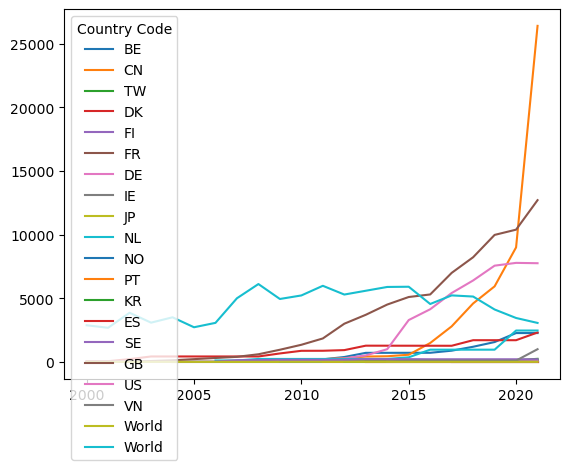

In [6]:
# test plot
tmp = df[df['Technology Name'] == 'Offshore Wind Energy']
tmp = tmp.set_index('Country Code')[all_years]
tmp.transpose().plot()

109


<Axes: >

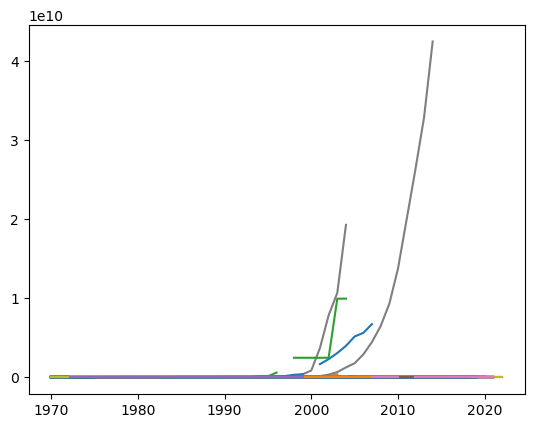

In [57]:
# test plot
tmp = df[df['Country Code'] == 'World']
tmp = tmp.drop_duplicates('Technology Name').set_index('Technology Name').loc[:, 1970:2022]
tmp = tmp.dropna(how='all')
print(len(tmp))
tmp.transpose().plot(legend=False)

<Axes: >

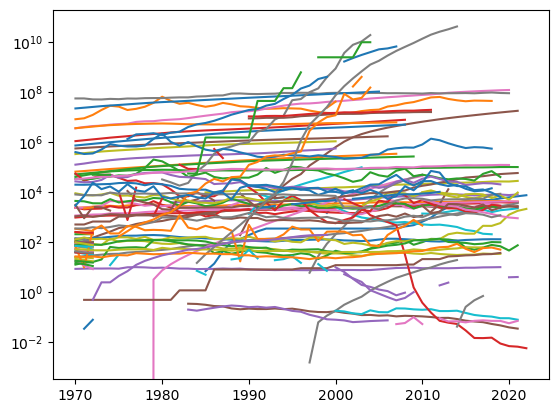

In [58]:
tmp.transpose().plot(legend=False, logy = True)

62


<Axes: >

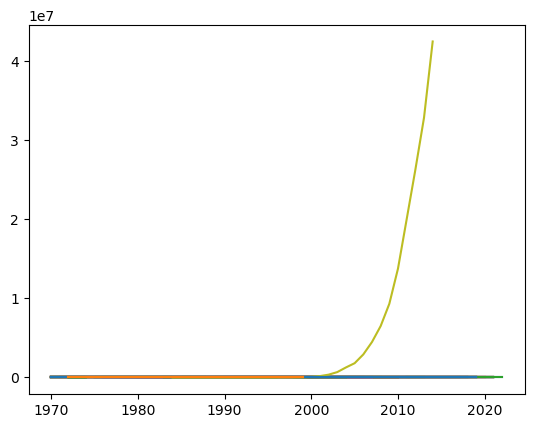

In [59]:
# normalize

for tech in tmp.index:
    tmp.loc[tech] = tmp.loc[tech] / tmp.loc[tech, 1990]

tmp = tmp.dropna(how='all')
print(len(tmp))

tmp.transpose().plot(legend=False)

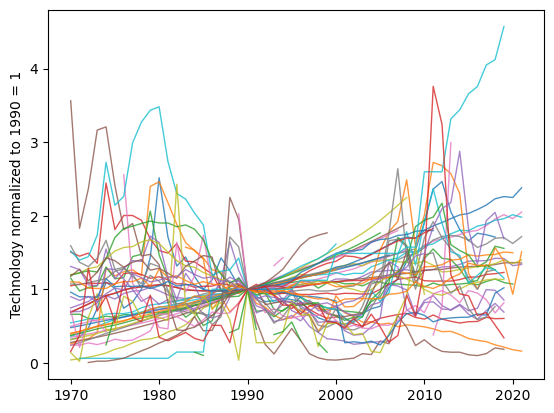

In [62]:
tmp[~(tmp > 5).any(axis=1)].transpose().plot(legend=False, lw=1, alpha=0.8)
plt.ylabel('Technology normalized to 1990 = 1')
plt.savefig('figures/timeseries_sample_normalized.png', bbox_inches='tight')